# Ejercicio 03 · Corpus público y clasificador de texto reproducible

Marlenis Judith Concepción Cuevas · INF-8239-C2 · Unidad II

**Pregunta.** ¿Puede un clasificador basado en TF-IDF separar SMS no deseados (`spam`) de mensajes legítimos (`ham`) con un F1 macro claramente superior a una línea base, sin que los mensajes repetidos inflen el resultado?

**Corpus.** SMS Spam Collection (UCI 228, CC BY 4.0, DOI 10.24432/C5CC84). La comparación con el segundo candidato está en `docs/dataset_candidates.csv` y la ficha completa en `docs/DATASET_CARD.md`.

El cuaderno llama al mismo código de `src/` y `scripts/` que se ejecuta desde la terminal.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT))

import json
import pandas as pd
from IPython.display import Image, display

from scripts.download_data import main as download
from scripts.audit_data import audit
from inf8239_u02.experiment import run

pd.set_option("display.max_colwidth", 120)
pd.read_csv(ROOT / "docs/dataset_candidates.csv")

,name,url,license,language,rows,target,decision
0,SMS Spam Collection,https://archive.ics.uci.edu/dataset/228/sms+spam+collection,CC BY 4.0,inglés,5574,label (ham/spam),seleccionado
1,Sentiment Labelled Sentences,https://archive.ics.uci.edu/dataset/331/sentiment+labelled+sentences,CC BY 4.0,inglés,3000,sentimiento (0/1),descartado


## 1. Descarga verificada (LAB04)
Se descarga el ZIP de UCI y se comprueba su SHA-256 antes de usarlo.

In [2]:
assert download() == 0

Archivo ZIP verificado. SHA-256: 1587ea43e58e82b14ff1f5425c88e17f8496bfcdb67a583dbff9eefaf9963ce3
Guardado: data/raw/sms_spam.csv · 5574 filas


## 2. Auditoría del corpus

In [3]:
summary = audit()
{k: summary[k] for k in ["filas", "nulos", "distribucion", "proporcion", "duplicados", "grupos_repetidos"]}

{'filas': 5574,
 'nulos': {'id': 0, 'text': 0, 'label': 0},
 'distribucion': {'ham': 4827, 'spam': 747},
 'proporcion': {'ham': 0.866, 'spam': 0.134},
 'duplicados': {'filas_originales': 5574,
  'duplicados_exactos': 403,
  'duplicados_normalizados': 434,
  'duplicados_solo_por_normalizacion': 31,
  'etiquetas_contradictorias': 0,
  'filas_finales': 5140},
 'grupos_repetidos': 300}

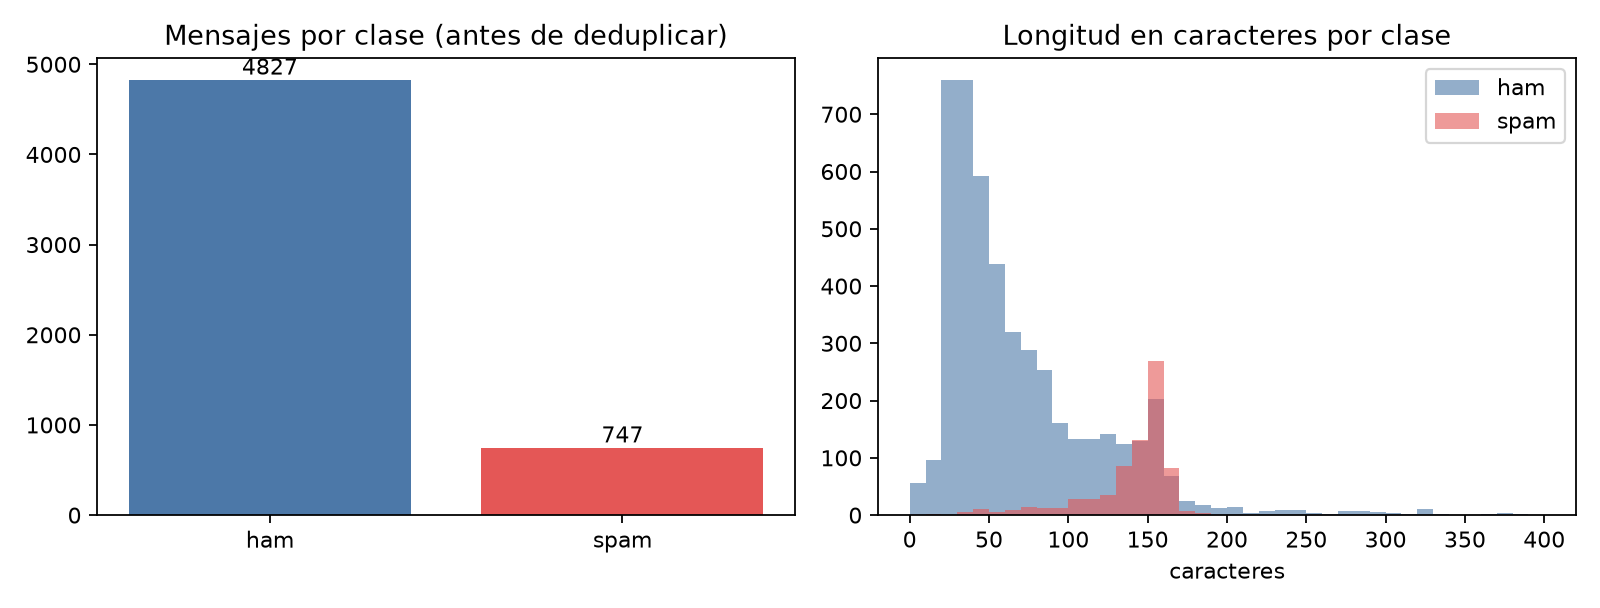

,veces,label,ejemplo
0,30,ham,"Sorry, I'll call later"
1,12,ham,I cant pick the phone right now. Pls send a message
2,10,ham,Ok...
3,4,ham,"Say this slowly.? GOD,I LOVE YOU &amp; I NEED YOU,CLEAN MY HEART WITH YOUR BLOOD.Send this to Ten special people &am..."
4,4,ham,Ok
5,4,ham,"7 wonders in My WORLD 7th You 6th Ur style 5th Ur smile 4th Ur Personality 3rd Ur Nature 2nd Ur SMS and 1st ""Ur Love..."
6,4,ham,Your opinion about me? 1. Over 2. Jada 3. Kusruthi 4. Lovable 5. Silent 6. Spl character 7. Not matured 8. Stylish 9...
7,4,ham,Ok.


In [4]:
display(Image(filename=str(ROOT / "reports/auditoria.png")))
pd.read_csv(ROOT / "reports/duplicados_frecuentes.csv").head(8)

**Observación.** Hay 434 mensajes repetidos al normalizar (403 exactos) y ninguna etiqueta contradictoria.
**Decisión.** Se eliminan antes de partir los datos, para que una misma plantilla no aparezca en entrenamiento y en prueba.

## 3. Partición, línea base y dos pipelines comparables (LAB05)
Partición estratificada 70/15/15 con semilla 42. Naive Bayes y regresión logística usan la misma rejilla de TF-IDF y la misma validación cruzada de 5 pliegues sobre entrenamiento.

In [5]:
out = run()
print("Deduplicación:", out["dedup"])
pd.DataFrame(out["splits"]).T

Deduplicación: {'filas_originales': 5574, 'duplicados_exactos': 403, 'duplicados_normalizados': 434, 'duplicados_solo_por_normalizacion': 31, 'etiquetas_contradictorias': 0, 'filas_finales': 5140}


,ham,spam
train,3162,436
valid,677,94
test,678,93


In [6]:
out["cv"]

,modelo,mejores_parametros,f1_macro_cv,f1_macro_cv_std,combinaciones,segundos_busqueda
0,naive_bayes,"{""model__alpha"": ""0.1"", ""tfidf__min_df"": ""1"", ""tfidf__ngram_range"": ""(1, 2)""}",0.961257,0.007173,12,2.646257
1,logistic,"{""model__C"": ""10.0"", ""tfidf__min_df"": ""1"", ""tfidf__ngram_range"": ""(1, 2)""}",0.963904,0.005197,12,3.501946


### Selección en validación
El modelo se elige con validación y la decisión se guarda antes de mirar la prueba.

In [7]:
display(out["valid"].round(4))
out["decision"]

,modelo,f1_macro,accuracy,precision_spam,recall_spam,f1_spam,recall_ham
0,dummy,0.4675,0.8781,0.0000,0.0000,0.0000,1.0000
1,naive_bayes,0.9544,0.9805,0.9247,0.9149,0.9198,0.9897
2,logistic,0.9539,0.9805,0.9341,0.9043,0.9189,0.9911


{'modelo_elegido': 'naive_bayes',
 'criterio': 'F1 macro en validación; desempate por recall de spam',
 'tomada_antes_de_test': True}

## 4. Evaluación en prueba

In [8]:
cols = ["modelo", "f1_macro_valid", "f1_macro_test", "accuracy_test", "precision_spam_test",
        "recall_spam_test", "recall_ham_test", "inferencia_ms_por_texto", "tamano_kb"]
out["results"][cols].round(4)

,modelo,f1_macro_valid,f1_macro_test,accuracy_test,precision_spam_test,recall_spam_test,recall_ham_test,inferencia_ms_por_texto,tamano_kb
0,dummy,0.4675,0.4679,0.8794,0.0000,0.0000,1.0000,0.0108,862.2197
1,naive_bayes,0.9544,0.9755,0.9896,0.9570,0.9570,0.9941,0.0124,2355.8604
2,logistic,0.9539,0.9694,0.9870,0.9462,0.9462,0.9926,0.0136,1161.1758


,clase,precision,recall,f1,soporte
0,ham,0.994,0.994,0.994,678.0
1,spam,0.957,0.957,0.957,93.0


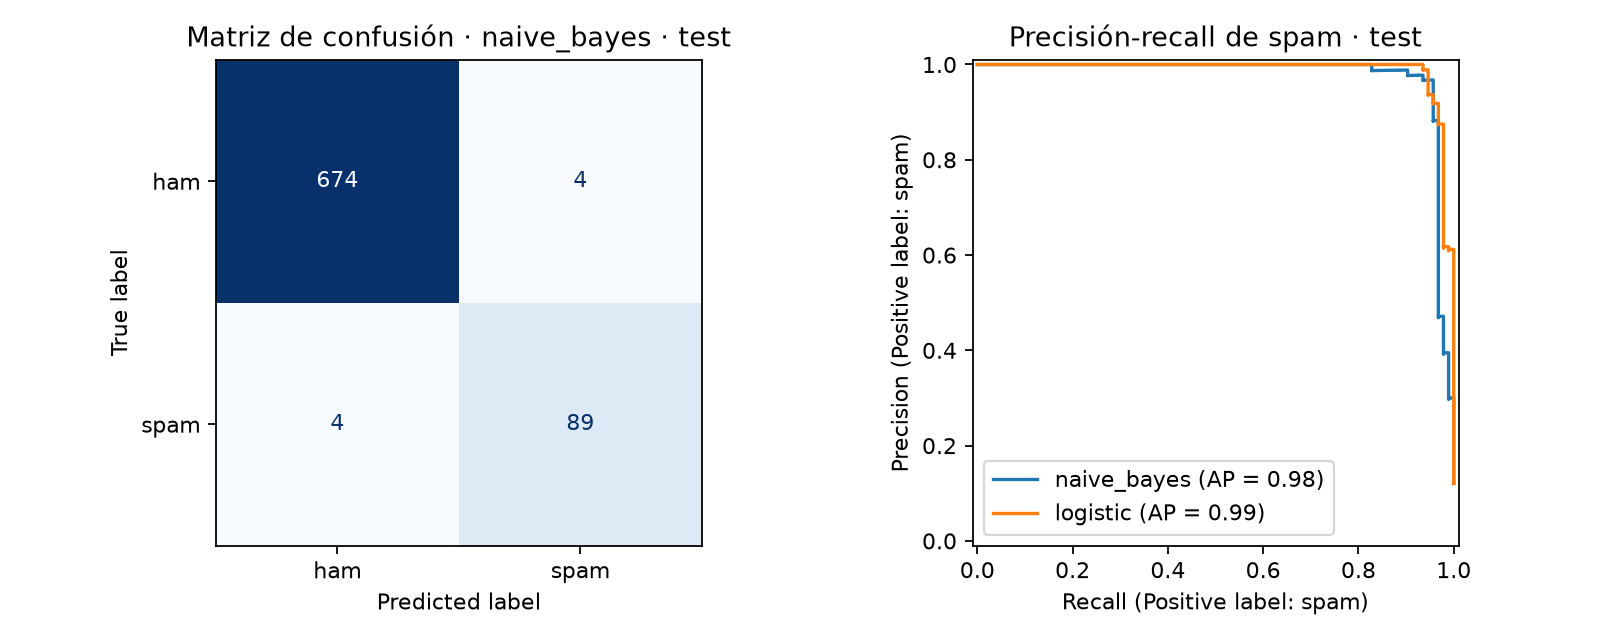

In [9]:
display(pd.read_csv(ROOT / "reports/metricas_por_clase.csv").round(3))
Image(filename=str(ROOT / "reports/confusion_text.png"))

## 5. Análisis de errores
Se revisan los 8 errores de prueba del modelo elegido y se completa con los 15 de validación para superar el mínimo de 20. Las categorías se asignaron leyendo cada mensaje (`docs/error_categories.csv`).

In [10]:
errors = out["errors"]
display(errors.groupby(["categoria", "real"]).size().rename("errores").reset_index())
errors[["id", "particion", "real", "predicho", "prob_spam", "text", "categoria"]]

,categoria,real,errores
0,Etiqueta dudosa de la fuente,spam,7
1,Fragmento de mensaje dividido,spam,1
2,Spam con tono personal,spam,2
3,Spam sin señales típicas,spam,2
4,Texto corto con palabras poco frecuentes,ham,4
5,Vocabulario comercial en mensaje legítimo,ham,7


,id,particion,real,predicho,prob_spam,text,categoria
0,3890,test,ham,spam,0.839,Unlimited texts. Limited minutes.,Vocabulario comercial en mensaje legítimo
1,1430,test,spam,ham,0.071,For sale - arsenal dartboard. Good condition but no doubles or trebles!,Etiqueta dudosa de la fuente
2,3603,test,ham,spam,0.554,Cps is causing the outages to conserve energy.,Texto corto con palabras poco frecuentes
3,495,test,ham,spam,0.656,Are you free now?can i call now?,Vocabulario comercial en mensaje legítimo
4,991,test,ham,spam,0.934,26th OF JULY,Texto corto con palabras poco frecuentes
5,2823,test,spam,ham,0.029,ROMCAPspam Everyone around should be responding well to your presence since you are so warm and outgoing. You are br...,Etiqueta dudosa de la fuente
6,4914,test,spam,ham,0.327,"Goal! Arsenal 4 (Henry, 7 v Liverpool 2 Henry scores with a simple shot from 6 yards from a pass by Bergkamp to give...",Spam sin señales típicas
7,4069,test,spam,ham,0.048,TBS/PERSOLVO. been chasing us since Sept for£38 definitely not paying now thanks to your information. We will ignore...,Etiqueta dudosa de la fuente
8,5372,valid,spam,ham,0.031,dating:i have had two of these. Only started after i sent a text to talk sport radio last week. Any connection do yo...,Etiqueta dudosa de la fuente
9,4862,valid,ham,spam,0.982,Nokia phone is lovly..,Vocabulario comercial en mensaje legítimo


## 6. Interpretación

| | |
|---|---|
| **Observación** | La línea base obtiene F1 macro 0.468 en prueba porque nunca predice spam. Naive Bayes llega a 0.976 y regresión logística a 0.969. |
| **Evidencia** | En validación la diferencia fue mínima (0.9544 frente a 0.9539); en validación cruzada ganó la logística (0.964 frente a 0.961). Naive Bayes comete 4 falsos positivos y 4 falsos negativos en 771 mensajes de prueba. |
| **Interpretación** | Los dos pipelines son prácticamente equivalentes; la ventaja de Naive Bayes no es concluyente. De los 23 errores, 7 corresponden a etiquetas dudosas de la fuente (comentarios del foro etiquetados como spam) y 7 a mensajes legítimos con vocabulario comercial. |
| **Decisión** | Se usa Naive Bayes porque ganó con la regla fijada antes de la prueba. Para un uso real haría falta revisar las etiquetas del foro, representar los números premium como un rasgo propio y validar con mensajes actuales. |